In [10]:
import os
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, wasserstein_distance, chisquare, norm
import matplotlib.pyplot as plt
from collections import deque
import numpy as np
import requests as re
from ast import literal_eval
from MFDFA import MFDFA

In [11]:
%matplotlib inline

# Project Setup

In [12]:
PROJECT_ROOT_DIR = "./."
BASE_IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images")
os.makedirs(BASE_IMAGES_PATH, exist_ok = True)

def save_figure(fig_id, image_path, tight_layout = True, fig_extension = "png", resolution = 300):
    path = os.path.join(image_path, fig_id + "." + fig_extension)
    print(f"Saving figure {fig_id}")
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format = fig_extension, dpi = resolution)

# Generators

In [13]:
class Qrng:
    def __init__(self, domain) -> None:
        self.__domain = domain
        self.__api_int = "https://{}/api/2.0/int".format(self.__domain)

    def qrand_int(self, low, hi, samples) -> list[int]:
        session = re.Session()
        payload = {"min": low, "max": hi, "quantity": samples}
        response = session.get(self.__api_int, params = payload)
        res = literal_eval(response.text)
        return res

def qrandint(l, h, n, pool_size = 100000) -> np.array:
    if not hasattr(qrandint, "ivalues"):
       qrandint.ivalues = {}

    key = str(l) + str(h)
    if key in qrandint.ivalues:
        # found the key
        values = qrandint.ivalues[key]
        if len(values) == 0 or len(values) < n:
            qrng = Qrng("random.cs.upt.ro")
            values = qrng.qrand_int(l, h, (n + pool_size))
            qrandint.ivalues[key] += values
        else:
            pass
    else:
        qrng = Qrng("random.cs.upt.ro")
        qrandint.ivalues[key] = qrng.qrand_int(l, h, (n + pool_size))

    outvals = qrandint.ivalues[key][:n]
    del qrandint.ivalues[key][:n]
    return np.array(outvals, dtype = np.uint32)

## Configuration

In [14]:
RANGE_MIN = 0
RANGE_MAX = 1000
ARRAY_SIZE = 10000

In [15]:
trng = qrandint(RANGE_MIN, RANGE_MAX + 1, ARRAY_SIZE, pool_size = 100000)
prng = np.random.randint(RANGE_MIN, RANGE_MAX + 1, size = ARRAY_SIZE)

# MFDFA

In [16]:
lag = np.logspace(0.7, 4, 30).astype(int)

# q values (moments)
# Select a list of powers q
q_list = np.linspace(-10,10,41)
q_list = q_list[q_list!=0.0]
order = 2
# Compute MFDFA
lag_t, dfa_t = MFDFA(trng, lag = lag, q = q_list, order = order)
lag_p, dfa_p = MFDFA(prng, lag = lag, q = q_list, order = order)

(30, 40)


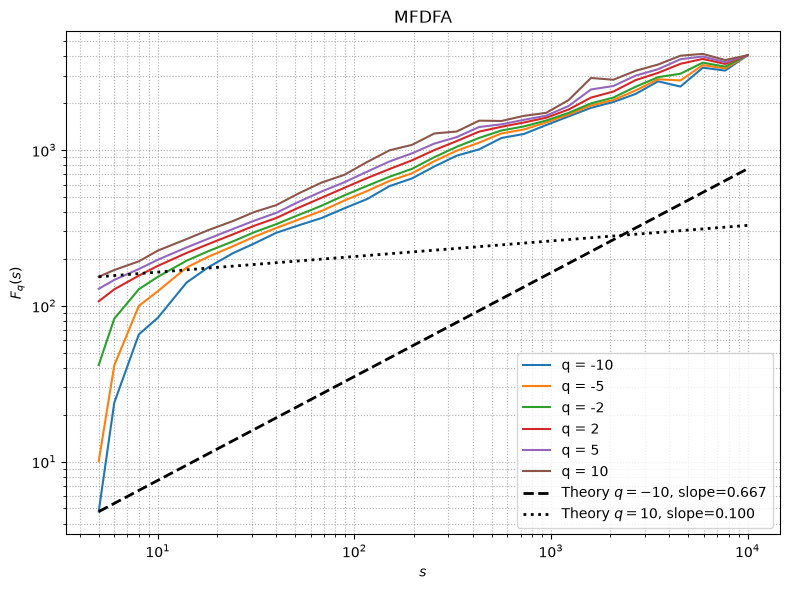

In [17]:
print(f"{dfa_t.shape}")
# Selected q values
q_selected = [-10, -5, -2, 2, 5, 10]

fig, ax = plt.subplots(figsize=(8, 6))

# Plot MFDFA curves
for q in q_selected:
    idx = np.where(q_list == q)[0][0]
    ax.loglog(lag_t, dfa_t[:, idx], label=f"q = {q}")

# ------------------------------------------------------------------
# Theoretical slope for q = -10: h(q) = 1/alpha = 1/1.5
# ------------------------------------------------------------------
alpha = 1.5
h_neg10 = 1 / alpha

idx_neg10 = np.where(q_list == -10)[0][0]
ref_x = lag_t
ref_y = dfa_t[0, idx_neg10] * (ref_x / lag_t[0])**h_neg10

ax.loglog(
    ref_x,
    ref_y,
    "k--",
    linewidth=2,
    label=rf"Theory $q=-10$, slope={h_neg10:.3f}"
)

# ------------------------------------------------------------------
# Theoretical slope for q = 10: h(q) = 1/q = 1/10
# ------------------------------------------------------------------
h_pos10 = 1 / 10

idx_pos10 = np.where(q_list == 10)[0][0]
ref_y = dfa_t[0, idx_pos10] * (ref_x / lag_t[0])**h_pos10

ax.loglog(
    ref_x,
    ref_y,
    "k:",
    linewidth=2,
    label=rf"Theory $q=10$, slope={h_pos10:.3f}"
)

ax.set_xlabel(r"$s$")
ax.set_ylabel(r"$F_q(s)$")
ax.set_title("MFDFA")
ax.legend()
ax.grid(True, which="both", ls=":")
plt.tight_layout()
plt.show()


(30, 40)


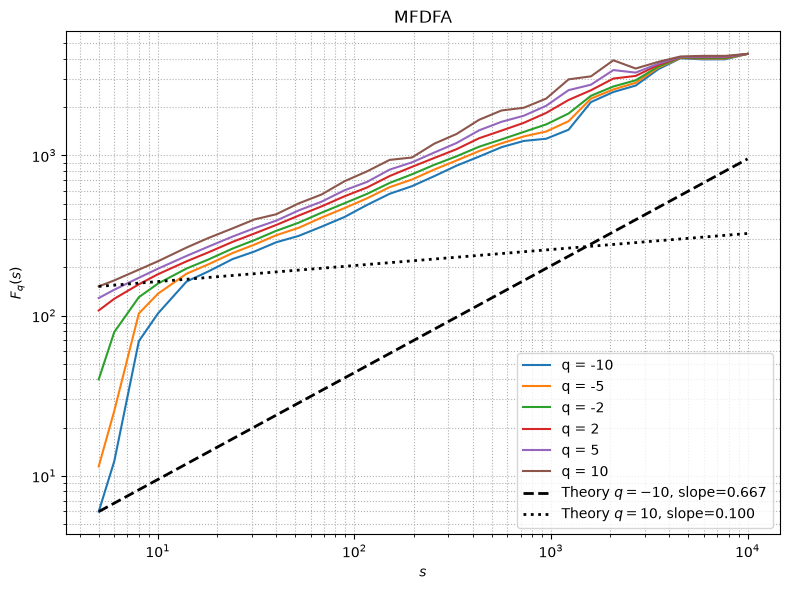

In [21]:
print(f"{dfa_p.shape}")
# Selected q values
q_selected = [-10, -5, -2, 2, 5, 10]

fig, ax = plt.subplots(figsize=(8, 6))

# Plot MFDFA curves
for q in q_selected:
    idx = np.where(q_list == q)[0][0]
    ax.loglog(lag_p, dfa_p[:, idx], label=f"q = {q}")

# ------------------------------------------------------------------
# Theoretical slope for q = -10: h(q) = 1/alpha = 1/1.5
# ------------------------------------------------------------------
alpha = 1.5
h_neg10 = 1 / alpha

idx_neg10 = np.where(q_list == -10)[0][0]
ref_x = lag_p
ref_y = dfa_p[0, idx_neg10] * (ref_x / lag_p[0])**h_neg10

ax.loglog(
    ref_x,
    ref_y,
    "k--",
    linewidth=2,
    label=rf"Theory $q=-10$, slope={h_neg10:.3f}"
)

# ------------------------------------------------------------------
# Theoretical slope for q = 10: h(q) = 1/q = 1/10
# ------------------------------------------------------------------
h_pos10 = 1 / 10

idx_pos10 = np.where(q_list == 10)[0][0]
ref_y = dfa_p[0, idx_pos10] * (ref_x / lag_p[0])**h_pos10

ax.loglog(
    ref_x,
    ref_y,
    "k:",
    linewidth=2,
    label=rf"Theory $q=10$, slope={h_pos10:.3f}"
)

ax.set_xlabel(r"$s$")
ax.set_ylabel(r"$F_q(s)$")
ax.set_title("MFDFA")
ax.legend()
ax.grid(True, which="both", ls=":")
plt.tight_layout()
plt.show()

Applying multifractal detrended fluctuation analysis confirms that both TRNG and PRNG sequences exhibit behavior consistent with uncorrelated white noise, showing no significant long-range dependencies or multifractal structure. Consequently, this method does not provide additional discriminatory power between the two generators.
